#### 1. Configuração Inicial e Hardware
Importação das bibliotecas base e recarga automática dos módulos locais (`config` e `detectors`). Deteção do hardware disponível (CPU ou GPU/CUDA) para execução otimizada no PyTorch.

In [13]:
import os
import time
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import importlib
import torch

# Importar os teus módulos
import src.config as cfg
import src.detectors as detectors
import src.descriptors as descriptors
import src.matching as matching
import src.homography as homography
import src.evaluation as evaluation

importlib.reload(cfg)
importlib.reload(detectors)
importlib.reload(descriptors)
importlib.reload(evaluation)

cfg.RESULTS_DIR.mkdir(parents=True, exist_ok=True)


device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"PyTorch a usar: {device.upper()}")
if device == "cuda":
    print(f"Placa Gráfica: {torch.cuda.get_device_name(0)}")

PyTorch a usar: CPU


#### Etapa 2: Carregamento de Imagem e Deteção de Keypoints
Leitura de uma imagem de teste do dataset (ex: GRAF) e aplicação do detetor instanciado (SIFT). Os *keypoints* encontrados são desenhados sobre a imagem original para validação visual da distribuição e densidade dos pontos de interesse.

In [18]:
import time
import cv2
import json
import numpy as np

# --- 1. PREPARAÇÃO ---
# --- 1. PREPARAÇÃO ---
combinacoes = [
    ('SIFT', None),            # SIFT + descriptor matching
    ('ORB', None),             # ORB + Hamming matching
    ('KAZE', None),            # KAZE + descriptor matching
    ('FAST', 'BRIEF_LIB'),     # FAST + binary descriptor (BRIEF)
    ('FAST', 'BRISK'),         # FAST + binary descriptor (BRISK)
    ('FAST', 'FREAK')          # FAST + binary descriptor (FREAK)
]

img1_path = cfg.DATA_DIR / "graf" / "img1.ppm"
img2_path = cfg.DATA_DIR / "graf" / "img2.ppm"
img4_path = cfg.DATA_DIR / "graf" / "img4.ppm"

img1 = cv2.imread(str(img1_path))
img2 = cv2.imread(str(img2_path))
img4 = cv2.imread(str(img4_path))

# CORREÇÃO: Verificar se carregaram ANTES de aplicar o cvtColor
if img1 is None or img2 is None or img4 is None: 
    raise FileNotFoundError(f"Erro ao carregar imagens. Verifica os caminhos.")

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img4_rgb = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

todas_metricas = {}

# --- 2. CICLO DA PIPELINE ---
# Nota: Vamos focar-nos na Imagem 1 vs Imagem 2. 
# Podes usar a Imagem 4 depois para um teste de Viewpoint severo.
for det_name, desc_name in combinacoes:
    comb_name = f"{det_name}_{desc_name}" if desc_name else det_name
    print(f"\n[{comb_name}] A processar...")
    
    # Criar subpasta para esta combinação
    comb_dir = cfg.RESULTS_DIR / comb_name
    comb_dir.mkdir(parents=True, exist_ok=True)
    
    metricas = {}
    
    # --- PASSO A: DETEÇÃO E DESCRIÇÃO ---
    t0 = time.time()
    
    det = detectors.get_detector(det_name)
    kps1 = detectors.detect_keypoints(img1, det)
    if desc_name:
        desc_obj = descriptors.create_descriptor(desc_name)
        kps1, des1 = descriptors.compute_descriptor(desc_obj, img1_rgb, kps1)
    else:
        kps1, des1 = descriptors.compute_descriptor(det, img1_rgb, kps1)
        
    kps2 = detectors.detect_keypoints(img2, det)
    if desc_name:
        kps2, des2 = descriptors.compute_descriptor(desc_obj, img2_rgb, kps2)
    else:
        kps2, des2 = descriptors.compute_descriptor(det, img2_rgb, kps2)
        
    t_extract = time.time() - t0
    
    num_features = (len(kps1) + len(kps2)) / 2
    metricas['Num_Keypoints_Img1'] = len(kps1)
    metricas['Num_Keypoints_Img2'] = len(kps2)
    metricas['Descriptor_Dim'] = des1.shape[1] if des1 is not None else 0
    metricas['Memory_Usage_Bytes'] = des1.nbytes + des2.nbytes if des1 is not None else 0
    metricas['Runtime_Extraction_s'] = round(t_extract, 4)

    # --- PASSO B: MATCHING ---
    t0 = time.time()
    norm_name = desc_name if desc_name else det_name
    matcher = matching.get_matcher(norm_name)
    bons_matches = matching.match_and_filter(matcher, des1, des2, ratio_thresh=0.8)
    t_match = time.time() - t0
    
    metricas['Runtime_Matching_s'] = round(t_match, 4)
    
    # --- PASSO C: HOMOGRAFIA E AVALIAÇÃO ---
    t0 = time.time()
    H, mask, src_pts, dst_pts = homography.calculate_homography(kps1, kps2, bons_matches, ransac_thresh=3.0)
    t_homography = time.time() - t0
    
    metricas['Runtime_Homography_s'] = float(round(t_homography, 4))
    
    # Avaliar o erro e calcular inliers reais (< 3 pixels)
    avg_error, correct_mask = evaluation.compute_reprojection_error(src_pts, dst_pts, H)
    
    # FORÇAR CONVERSÃO PARA INT E FLOAT AQUI:
    num_correct = int(np.sum(correct_mask)) 
    metricas['Reprojection_Error_Avg'] = float(round(avg_error, 4))
    
    # Calcular PMR, Precision e Matching Score
    metrics_oficiais = evaluation.compute_evaluation_metrics(
        num_features=float(num_features), 
        num_putative=len(bons_matches), 
        num_correct=num_correct
    )
    
    # Garantir que todos os valores atualizados são float nativos
    metricas.update({k: float(round(v, 4)) if v is not None else None for k, v in metrics_oficiais.items()})
    
    # --- PASSO D: GUARDAR IMAGENS E RESULTADOS ---
    # Desenhar matches corretos (inliers) a verde e incorretos (outliers) a vermelho
    # Adicionámos .astype(int) antes do .tolist()
    draw_params = dict(
        matchColor=(0, 255, 0), 
        singlePointColor=(255, 0, 0),
        matchesMask=correct_mask.astype(int).tolist(), 
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    img_matches = cv2.drawMatches(img1_rgb, kps1, img2_rgb, kps2, bons_matches, None, **draw_params)
    
    # Guardar a imagem na pasta correta
    cv2.imwrite(str(comb_dir / "correct_vs_incorrect_matches.jpg"), cv2.cvtColor(img_matches, cv2.COLOR_RGB2BGR))
    
    # Guardar dados
    todas_metricas[comb_name] = metricas
    with open(comb_dir / "metrics.json", "w") as f:
        json.dump(metricas, f, indent=4)
        
    print(f"-> Concluído: {int(num_correct)} matches corretos | Erro Reprojeção: {round(avg_error, 2)} px")

# Guardar dicionário final com tudo
with open(cfg.RESULTS_DIR / "all_results_comparison.json", "w") as f:
    json.dump(todas_metricas, f, indent=4)
print("\nProcessamento completo!")


[SIFT] A processar...
-> Concluído: 450 matches corretos | Erro Reprojeção: 11.949999809265137 px

[ORB] A processar...
-> Concluído: 222 matches corretos | Erro Reprojeção: 2.369999885559082 px

[KAZE] A processar...
-> Concluído: 596 matches corretos | Erro Reprojeção: 4.690000057220459 px

[FAST_BRIEF_LIB] A processar...
-> Concluído: 63 matches corretos | Erro Reprojeção: 26.43000030517578 px

[FAST_BRISK] A processar...
-> Concluído: 677 matches corretos | Erro Reprojeção: 13.729999542236328 px

[FAST_FREAK] A processar...
-> Concluído: 739 matches corretos | Erro Reprojeção: 8.430000305175781 px

Processamento completo!


In [17]:
import pandas as pd
from IPython.display import display

# 1. Converter o dicionário de resultados num DataFrame do Pandas
df_resultados = pd.DataFrame.from_dict(todas_metricas, orient='index')

# 2. TABELA 1: Desempenho e Qualidade de Correspondência
cols_desempenho = [
    'Num_Keypoints_Img1', 
    'Num_Putative_Matches', 
    'PMR', 
    'Precision', 
    'Matching_Score', 
    'Reprojection_Error_Avg'
]
print("--- TABELA 1: Desempenho e Correspondência ---")
display(df_resultados[cols_desempenho])

# 3. TABELA 2: Tempo de Execução e Custo Computacional
cols_computacional = [
    'Runtime_Extraction_s', 
    'Runtime_Matching_s', 
    'Runtime_Homography_s', 
    'Descriptor_Dim', 
    'Memory_Usage_Bytes'
]
print("\n--- TABELA 2: Custo Computacional ---")
display(df_resultados[cols_computacional])

# (Opcional) Guardar em CSV para facilitar a passagem para o relatório PDF
df_resultados.to_csv(cfg.RESULTS_DIR / "tabelas_relatorio.csv")

--- TABELA 1: Desempenho e Correspondência ---


KeyError: "['Num_Putative_Matches'] not in index"

In [ ]:
import cv2
import numpy as np
from scipy.spatial import KDTree
import time

# --- FUNÇÕES DE TRANSFORMAÇÃO SINTÉTICA ---
def get_rotated_image(img, angle=45):
    h, w = img.shape[:2]
    center = (w / 2, h / 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    img_rot = cv2.warpAffine(img, M, (w, h))
    H_gt = np.vstack([M, [0, 0, 1]]) # Converter para 3x3
    return img_rot, H_gt

def get_scaled_image(img, scale=0.5):
    h, w = img.shape[:2]
    img_scaled = cv2.resize(img, (0, 0), fx=scale, fy=scale)
    H_gt = np.array([[scale, 0, 0], [0, scale, 0], [0, 0, 1]], dtype=np.float32)
    return img_scaled, H_gt

def compute_repeatability(kps1, kps2, H_gt, threshold=3.0):
    if len(kps1) == 0 or len(kps2) == 0: return 0.0
    
    # Extrair coordenadas e projetar kps1 com a H_gt
    pts1 = np.float32([kp.pt for kp in kps1]).reshape(-1, 1, 2)
    pts2 = np.array([kp.pt for kp in kps2])
    pts1_warped = cv2.perspectiveTransform(pts1, H_gt).reshape(-1, 2)
    
    # KDTree para encontrar os pontos mais próximos na img2 rapidamente
    tree = KDTree(pts2)
    distances, indices = tree.query(pts1_warped)
    
    # Calcular percentagem de pontos que caem dentro do threshold (ex: 3 pixéis)
    repeated = np.sum(distances <= threshold)
    return repeated / min(len(kps1), len(kps2))

# --- TESTAR REPETIBILIDADE ---
print("--- A INICIAR TESTES DE REPETIBILIDADE ---")
resultados_rep = {}

# Gerar as imagens transformadas
img_rot, H_rot = get_rotated_image(img1, angle=45)
img_sca, H_sca = get_scaled_image(img1, scale=0.5)

for det_name, desc_name in combinacoes:
    comb_name = f"{det_name}_{desc_name}" if desc_name else det_name
    det = detectors.get_detector(det_name)
    
    # Extrair na imagem original
    kps_orig = detectors.detect_keypoints(img1, det)
    
    # Extrair nas imagens transformadas
    kps_rot = detectors.detect_keypoints(img_rot, det)
    kps_sca = detectors.detect_keypoints(img_sca, det)
    
    # Calcular repetibilidade
    rep_rot = compute_repeatability(kps_orig, kps_rot, H_rot)
    rep_sca = compute_repeatability(kps_orig, kps_sca, H_sca)
    
    resultados_rep[comb_name] = {
        'Repetibilidade_Rotacao_45': round(rep_rot, 4),
        'Repetibilidade_Escala_0.5': round(rep_sca, 4)
    }

# Exibir os resultados da repetibilidade
df_rep = pd.DataFrame.from_dict(resultados_rep, orient='index')
display(df_rep)

In [3]:
# compute the descriptors with BRIEF
det = detectors.get_detector('SIFT')
    
# Agora que o código está modular, recebemos a lista de pontos diretamente!
kps = detectors.detect_keypoints(img1, det)
    
img_kp = cv2.drawKeypoints(
    img1_rgb, kps, None, 
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

ax.imshow(img_kp)
ax.set_title(f"{name}: {len(kps)} Keypoints", fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

brief = descriptors.create_descriptor('BRIEF_LIB')
kps, des = descriptors.compute_descriptor(brief, img1_rgb, kps)
print( des.shape )

<Figure size 640x480 with 0 Axes>

(783, 32)


In [ ]:
# --- 3. FUNÇÃO UNIFICADA DE EXTRAÇÃO (DETETOR + DESCRITOR) ---
def extrair_features(img_rgb, nome_detetor, nome_descritor=None):
    """
    Deteta keypoints e calcula descritores. 
    Se nome_descritor for None, assume que o detetor também extrai descritores (ex: SIFT).
    """
    # 1. Obter o detetor e detetar pontos
    det = detectors.get_detector(nome_detetor)
    kps = detectors.detect_keypoints(img_rgb, det)
    
    # 2. Calcular descritores
    if nome_descritor:
        # Ex: FAST deteta, BRIEF descreve
        desc = descriptors.create_descriptor(nome_descritor)
        kps, des = descriptors.compute_descriptor(desc, img_rgb, kps)
    else:
        # Ex: SIFT/ORB/KAZE fazem ambos
        kps, des = descriptors.compute_descriptor(det, img_rgb, kps)
        
    return kps, des

# --- 4. TESTAR COM SIFT NAS DUAS IMAGENS ---
print("--- A extrair features (SIFT) ---")
kps1, des1 = extrair_features(img1_rgb, 'SIFT')
kps2, des2 = extrair_features(img2_rgb, 'SIFT')

print(f"Imagem 1: {len(kps1)} keypoints | Descritores shape: {des1.shape}")
print(f"Imagem 2: {len(kps2)} keypoints | Descritores shape: {des2.shape}")

# --- 5. TESTAR COM FAST + BRIEF (Apenas para validar a lógica) ---
print("\n--- A extrair features (FAST + BRIEF) ---")
kps1_fast, des1_brief = extrair_features(img1_rgb, 'FAST', 'BRIEF_LIB')
kps2_fast, des2_brief = extrair_features(img2_rgb, 'FAST', 'BRIEF_LIB')

print(f"Imagem 1: {len(kps1_fast)} keypoints | Descritores shape: {des1_brief.shape}")
print(f"Imagem 2: {len(kps2_fast)} keypoints | Descritores shape: {des2_brief.shape}")

--- A extrair features (SIFT) ---
Imagem 1: 1081 keypoints | Descritores shape: (1081, 128)
Imagem 2: 1243 keypoints | Descritores shape: (1243, 128)

--- A extrair features (FAST + BRIEF) ---
Imagem 1: 2354 keypoints | Descritores shape: (2354, 32)
Imagem 2: 2615 keypoints | Descritores shape: (2615, 32)


SIFT -> Matches após ratio test: 487


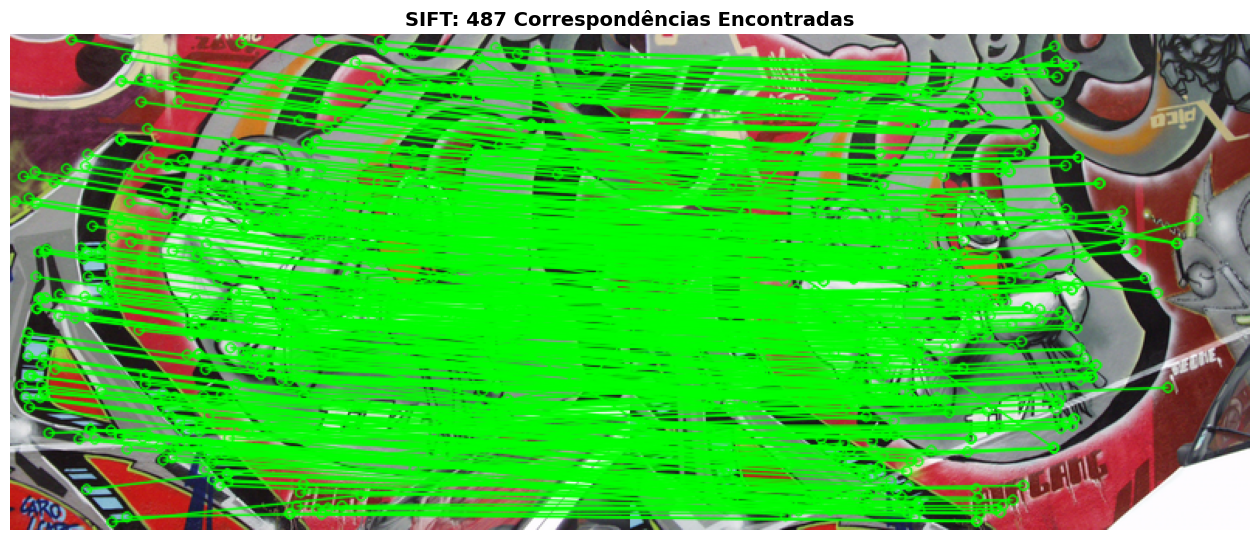

In [ ]:
import src.matching as matching
importlib.reload(matching)

# --- 1. CRIAR O MATCHER PARA SIFT ---
matcher_sift = matching.get_matcher('SIFT')

# --- 2. CALCULAR E FILTRAR MATCHES ---
bons_matches_sift = matching.match_and_filter(matcher_sift, des1, des2, ratio_thresh=0.8)
print(f"SIFT -> Matches após ratio test: {len(bons_matches_sift)}")

# --- 3. DESENHAR OS MATCHES ---
img_matches_sift = cv2.drawMatches(
    img1_rgb, kps1, 
    img2_rgb, kps2, 
    bons_matches_sift, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    matchColor=(0, 255, 0) # Desenha as linhas a verde
)

# --- 4. VISUALIZAR ---
plt.figure(figsize=(16, 8))
plt.imshow(img_matches_sift)
plt.title(f"SIFT: {len(bons_matches_sift)} Correspondências Encontradas", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

Total de Correspondências (Putative): 487
Total de Inliers (RANSAC): 457
Rácio de Inliers: 0.94


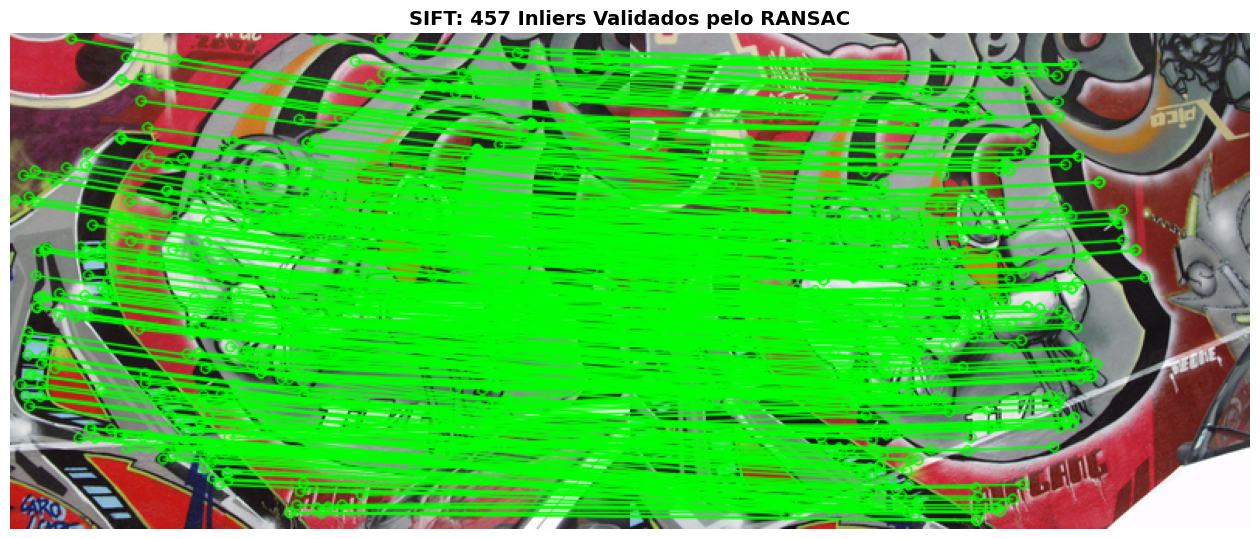

In [ ]:
import src.homography as homography
importlib.reload(homography)

# --- 1. CALCULAR A HOMOGRAFIA COM RANSAC ---
# Vamos usar os bons_matches_sift calculados no passo anterior
H_sift, mask_sift, src_pts, dst_pts = homography.calculate_homography(
    kps1, kps2, bons_matches_sift, ransac_thresh=3.0
)

# --- 2. REPORTAR MÉTRICAS DO GUIÃO ---
num_matches = len(bons_matches_sift)
num_inliers = sum(mask_sift)
inlier_ratio = num_inliers / num_matches if num_matches > 0 else 0

print(f"Total de Correspondências (Putative): {num_matches}")
print(f"Total de Inliers (RANSAC): {num_inliers}")
print(f"Rácio de Inliers: {inlier_ratio:.2f}")

# --- 3. VISUALIZAR APENAS OS INLIERS ---
img_inliers_sift = cv2.drawMatches(
    img1_rgb, kps1, 
    img2_rgb, kps2, 
    bons_matches_sift, None,
    matchesMask=mask_sift,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    matchColor=(0, 255, 0)
)

plt.figure(figsize=(16, 8))
plt.imshow(img_inliers_sift)
plt.title(f"SIFT: {num_inliers} Inliers Validados pelo RANSAC", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

In [ ]:
# Clone Github repository
!git clone https://github.com/magicleap/SuperGluePretrainedNetwork.git

# Download and extract HPatches Sequences
!wget https://huggingface.co/datasets/vbalnt/hpatches/resolve/main/hpatches-sequences-release.zip
!7z x hpatches-sequences-release.zip